# Complex Numbers — Lecture 9
## Concept of Rotation: The Rotating Factor $e^{i\alpha}$ · Three Cases · Equilateral Triangle Identity

**Source:** [Complex Numbers 09 | Concept of Rotation | Class 11 | JEE](https://youtu.be/kT0u3IoekYc), Physics Wallah (Class 11), about 41 min

**Prerequisite:** Lecture 3 (complex numbers as vectors), Lecture 5 (Euler form $re^{i\theta}$), and trigonometry: anticlockwise angles are positive, clockwise are negative.

**This is the last lecture of the chapter.** The lecturer suggests revising all previous notes before watching it.

### What this lecture covers
1. **What "rotation" means here:** turning a complex number, treated as a vector, about a point by an angle $\alpha$, and finding where it lands
2. **Case 1:** rotation about the origin, same modulus: $z_2 = z_1e^{i\alpha}$, with **$e^{i\alpha}$ the rotating factor**
3. Example: rotate $1 + i$ by $\frac{\pi}{6}$ anticlockwise
4. **Case 2:** rotation about the origin, modulus changes: use **unit vectors**
5. **Case 3 (general):** rotation about any point $z_0$, modulus may change: $\dfrac{z_2 - z_0}{|z_2 - z_0|} = \dfrac{z_1 - z_0}{|z_1 - z_0|}e^{i\alpha}$
6. **Question (old IIT):** if $z_1, z_2, z_3$ form an equilateral triangle, then $z_1^2 + z_2^2 + z_3^2 = z_1z_2 + z_2z_3 + z_3z_1$

> *(Not the physics kind of rotation, rotational motion and inertia. This is the complex-numbers concept of rotation.)*

Sections marked *(extra)* go beyond what was said in the lecture.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

# Same look as Lectures 1–8
BLUE, ORANGE, AQUA, VIOLET = "#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7"
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({
    "figure.dpi": 110, "axes.edgecolor": INK2, "axes.labelcolor": INK,
    "text.color": INK, "xtick.color": INK2, "ytick.color": INK2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
    "animation.embed_limit": 30,
})
rng = np.random.default_rng(9)

def argand(ax, lim=2.5, ticks=1):
    # Draw the complex plane: real axis horizontal, imaginary axis vertical
    ax.axhline(0, color=INK2, lw=1); ax.axvline(0, color=INK2, lw=1)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect("equal")
    t = np.arange(ticks, lim, ticks); t = np.r_[-t[::-1], 0, t]
    ax.set_xticks(t)
    ax.set_yticks(t, ["0" if v == 0 else "i" if v == 1 else "−i" if v == -1 else f"{v:g}i".replace("-", "−") for v in t])
    ax.set_xlabel("Re"); ax.set_ylabel("Im")

def arrow(ax, z0, z1, color, lw=2, ls="-"):
    z0, z1 = complex(z0), complex(z1)
    ax.annotate("", (z1.real, z1.imag), (z0.real, z0.imag),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=lw, ls=ls, mutation_scale=14, shrinkA=0, shrinkB=0))

def angle_arc(ax, a0, a1, r=0.5, center=0j, color=ORANGE, lw=2):
    # Arc from angle a0 to a1 around `center`, with an arrowhead showing the direction
    t = np.linspace(a0, a1, 80); c = complex(center)
    ax.plot(c.real + r*np.cos(t), c.imag + r*np.sin(t), color=color, lw=lw)
    ax.annotate("", (c.real + r*np.cos(t[-1]), c.imag + r*np.sin(t[-1])), (c.real + r*np.cos(t[-6]), c.imag + r*np.sin(t[-6])),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=lw, mutation_scale=12))

def rotate(z, alpha, about=0j, scale=1.0):
    # General rotation (Case 3): turn z about `about` by alpha, then stretch the arm by `scale`
    return about + scale*(z - about)*np.exp(1j*alpha)
print("ready")

ready


---
## 1. The Idea

From earlier lectures, a complex number can be treated as a **vector** (its position vector). **Rotation** asks:

> If I turn this vector about some point by an angle $\alpha$, and possibly stretch or shrink it, **which complex number does it land on?**

**Sign convention** (from trigonometry):
- **anticlockwise** rotation means $\alpha > 0$,
- **clockwise** rotation means $\alpha < 0$.

The lecturer builds the answer in **three cases**, from simplest to most general.

---
## 2. Case 1: Rotation About the Origin, Modulus Unchanged

**Given:** $z_1$ with $|z_1| = r$ and $\arg z_1 = \theta_1$. Rotate the segment $Oz_1$ about the origin by $\alpha$ (anticlockwise). It lands at $z_2$. **Find $z_2$.**

**Observations:**
- Rotation doesn't change length, so $|z_2| = r$.
- The new angle with the positive real axis is $\arg z_2 = \theta_1 + \alpha$.

**Write $z_2$ in Euler form (Lecture 5):**
$$z_2 = |z_2|\,e^{i\arg z_2} = r\,e^{i(\theta_1 + \alpha)} = \underbrace{r\,e^{i\theta_1}}_{=\,z_1}\cdot e^{i\alpha}$$
$$\boxed{z_2 = z_1\,e^{i\alpha}}$$

**$e^{i\alpha}$ is the rotating factor.** Multiplying any complex number by $e^{i\alpha}$ **rotates it by $\alpha$ about the origin** without changing its length. The whole concept of rotation is built on this factor.

*(This is why multiplying by $i = e^{i\pi/2}$ was a $90°$ turn in Lecture 1, and multiplying by $\omega = e^{i2\pi/3}$ a $120°$ turn in Lecture 7.)*

### Example: rotate $1 + i$ by $\frac{\pi}{6}$ anticlockwise about the origin
$$z_2 = (1 + i)\,e^{i\pi/6} = (1 + i)\left(\cos\frac{\pi}{6} + i\sin\frac{\pi}{6}\right) = (1 + i)\left(\frac{\sqrt3}{2} + \frac{i}{2}\right)$$
$$= \frac12\left(\sqrt3 + \sqrt3\,i + i + i^2\right) = \boxed{\frac{(\sqrt3 - 1) + i(\sqrt3 + 1)}{2}}$$
Check: $|z_2| = |1 + i| = \sqrt2$, and $\arg z_2 = \frac{\pi}{4} + \frac{\pi}{6} = \frac{5\pi}{12}$.

z2 = (0.366025+1.366025j)    formula: (0.366025+1.366025j)
|z1| = 1.414214, |z2| = 1.414214   arg z2 = 75.0° = 45° + 30°


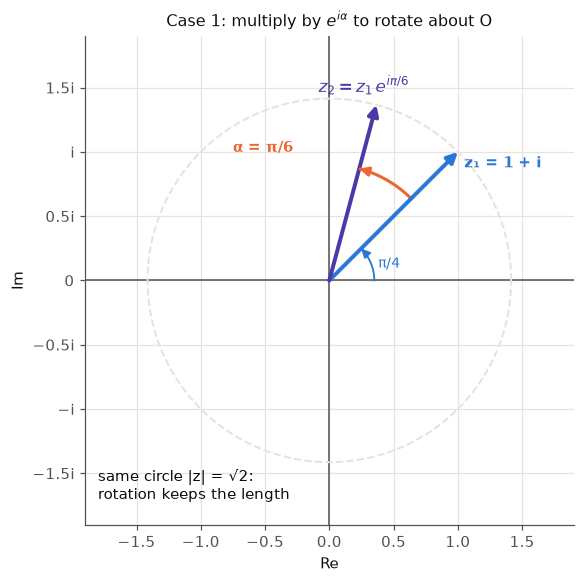

In [2]:
z1 = 1 + 1j; a = np.pi/6; z2 = z1*np.exp(1j*a)
print("z2 =", np.round(z2, 6), "   formula:", np.round(((np.sqrt(3) - 1) + 1j*(np.sqrt(3) + 1))/2, 6))
print(f"|z1| = {abs(z1):.6f}, |z2| = {abs(z2):.6f}   arg z2 = {np.degrees(np.angle(z2)):.1f}° = 45° + 30°")

fig, ax = plt.subplots(figsize=(6, 5.4)); argand(ax, lim=1.9, ticks=0.5)
c = np.linspace(0, 2*np.pi, 300); ax.plot(np.sqrt(2)*np.cos(c), np.sqrt(2)*np.sin(c), color=GRID, lw=1.3, ls="--")
arrow(ax, 0, z1, BLUE, 2.6); arrow(ax, 0, z2, VIOLET, 2.6)
angle_arc(ax, np.angle(z1), np.angle(z2), r=0.9)
angle_arc(ax, 0, np.angle(z1), r=0.35, color=BLUE, lw=1.2)
ax.text(z1.real + 0.05, z1.imag - 0.12, "z₁ = 1 + i", color=BLUE, weight="bold")
ax.text(z2.real - 0.45, z2.imag + 0.1, r"$z_2 = z_1\,e^{i\pi/6}$", color=VIOLET, fontsize=11)
ax.text(-0.75, 1.0, "α = π/6", color=ORANGE, weight="bold"); ax.text(0.38, 0.1, "π/4", color=BLUE, fontsize=9)
ax.text(-1.8, -1.7, "same circle |z| = √2:\nrotation keeps the length", fontsize=9.5)
ax.set_title(r"Case 1: multiply by $e^{i\alpha}$ to rotate about O", fontsize=10.5)
plt.tight_layout(); plt.show()

---
## 3. Case 2: Rotation About the Origin, Modulus Changes

Now $z_1$ is turned by $\alpha$ about the origin **and** stretched or shrunk, landing at $z_2$ with $|z_2| \ne |z_1|$ in general.

**Trick: reduce to Case 1 using unit vectors.** Dividing a vector by its length gives a **unit vector**, length 1, in the same direction:
$$\hat z_1 = \frac{z_1}{|z_1|}, \qquad \hat z_2 = \frac{z_2}{|z_2|}$$
Both have modulus 1, so Case 1 applies to them: rotating $\hat z_1$ by $\alpha$ gives $\hat z_2$.
$$\boxed{\frac{z_2}{|z_2|} = \frac{z_1}{|z_1|}\,e^{i\alpha}} \quad\Longleftrightarrow\quad z_2 = \frac{|z_2|}{|z_1|}\,z_1\,e^{i\alpha}$$
When $|z_2| = |z_1|$, this collapses back to Case 1.

z2 = (0.4266+2.5648j)   |z2| = 2.6   angle turned = 60.0 °
unit-vector form holds: True


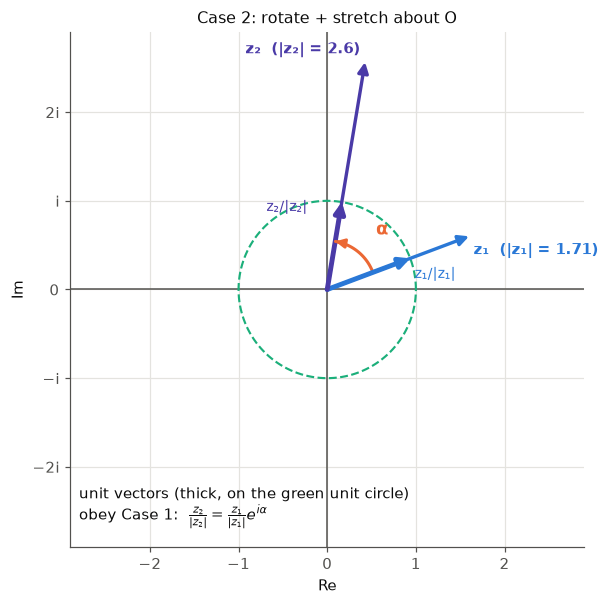

In [3]:
z1 = 1.6 + 0.6j; a = np.pi/3; R2 = 2.6
z2 = R2/abs(z1)*z1*np.exp(1j*a)
print("z2 =", np.round(z2, 4), "  |z2| =", round(abs(z2), 6), "  angle turned =", round(np.degrees(np.angle(z2/z1)), 3), "°")
print("unit-vector form holds:", np.isclose(z2/abs(z2), z1/abs(z1)*np.exp(1j*a)))

fig, ax = plt.subplots(figsize=(6.2, 5.6)); argand(ax, lim=2.9)
c = np.linspace(0, 2*np.pi, 300); ax.plot(np.cos(c), np.sin(c), color=AQUA, lw=1.4, ls="--")
arrow(ax, 0, z1, BLUE, 2.2); arrow(ax, 0, z2, VIOLET, 2.2)
u1, u2 = z1/abs(z1), z2/abs(z2)
arrow(ax, 0, u1, BLUE, 3.2); arrow(ax, 0, u2, VIOLET, 3.2)
angle_arc(ax, np.angle(z1), np.angle(z2), r=0.55)
ax.text(z1.real + 0.05, z1.imag - 0.2, f"z₁  (|z₁| = {abs(z1):.2f})", color=BLUE, weight="bold")
ax.text(z2.real - 1.35, z2.imag + 0.1, f"z₂  (|z₂| = {R2})", color=VIOLET, weight="bold")
ax.text(u1.real + 0.05, u1.imag - 0.22, "z₁/|z₁|", color=BLUE, fontsize=9); ax.text(u2.real - 0.85, u2.imag - 0.1, "z₂/|z₂|", color=VIOLET, fontsize=9)
ax.text(0.55, 0.62, "α", color=ORANGE, fontsize=12, weight="bold")
ax.text(-2.8, -2.6, "unit vectors (thick, on the green unit circle)\nobey Case 1:  " + r"$\frac{z_2}{|z_2|} = \frac{z_1}{|z_1|}e^{i\alpha}$", fontsize=10)
ax.set_title("Case 2: rotate + stretch about O", fontsize=10.5)
plt.tight_layout(); plt.show()

---
## 4. Case 3 (General): Rotation About Any Point $z_0$

Now the pivot is a general point $z_0$, not the origin. The arm $z_0 \to z_1$ is turned by $\alpha$ about $z_0$ and stretched, landing at $z_2$.

**Step 1: vectors from the pivot.** By the vector rule "$\vec{AB}$ = position vector of $B$ minus position vector of $A$":
$$\vec{z_0z_1} = z_1 - z_0, \qquad \vec{z_0z_2} = z_2 - z_0$$
**Step 2: unit vectors**, as in Case 2:
$$\frac{z_1 - z_0}{|z_1 - z_0|}, \qquad \frac{z_2 - z_0}{|z_2 - z_0|}$$
**Step 3: Case 1 on the unit vectors.** Multiply by the rotating factor:
$$\boxed{\frac{z_2 - z_0}{|z_2 - z_0|} = \frac{z_1 - z_0}{|z_1 - z_0|}\,e^{i\alpha}}$$
Rearranged to find $z_2$:
$$z_2 = z_0 + \frac{|z_2 - z_0|}{|z_1 - z_0|}\,(z_1 - z_0)\,e^{i\alpha}$$

**Special cases:**
- **Case 1:** $z_0 = 0$ and equal lengths.
- **Case 2:** $z_0 = 0$ and different lengths.

> The lecturer: *"Don't just mug up the formula. Remember the concept: unit vector, times the rotating factor, then scale back up. You can rebuild the formula in seconds."*

z2 = (0.7894+1.9j)
formula holds: True    |z2 − z0| = 1.4    turn = 72.0 °


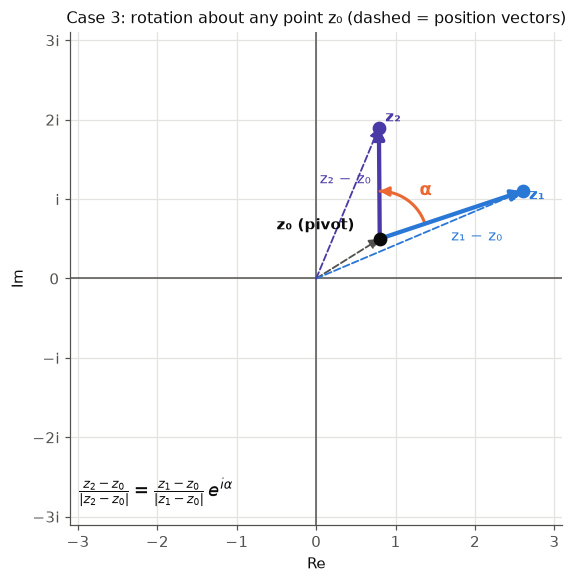

In [4]:
z0, z1, a, L2 = 0.8 + 0.5j, 2.6 + 1.1j, 2*np.pi/5, 1.4
z2 = rotate(z1, a, about=z0, scale=L2/abs(z1 - z0))
print("z2 =", np.round(z2, 4))
print("formula holds:", np.isclose((z2 - z0)/abs(z2 - z0), (z1 - z0)/abs(z1 - z0)*np.exp(1j*a)),
      "   |z2 − z0| =", round(abs(z2 - z0), 6), "   turn =", round(np.degrees(np.angle((z2 - z0)/(z1 - z0))), 3), "°")

fig, ax = plt.subplots(figsize=(6.6, 5.4)); argand(ax, lim=3.1)
arrow(ax, 0, z0, INK2, 1.2, ls="--"); arrow(ax, 0, z1, BLUE, 1.2, ls="--"); arrow(ax, 0, z2, VIOLET, 1.2, ls="--")
arrow(ax, z0, z1, BLUE, 2.8); arrow(ax, z0, z2, VIOLET, 2.8)
angle_arc(ax, np.angle(z1 - z0), np.angle(z2 - z0), r=0.6, center=z0)
for z, lab, col, off in [(z0, "z₀ (pivot)", INK, (-1.3, 0.12)), (z1, "z₁", BLUE, (0.08, -0.1)), (z2, "z₂", VIOLET, (0.08, 0.08))]:
    ax.plot(z.real, z.imag, "o", color=col, ms=8, zorder=5); ax.text(z.real + off[0], z.imag + off[1], lab, color=col, weight="bold")
ax.text(z0.real + 0.5, z0.imag + 0.55, "α", color=ORANGE, fontsize=12, weight="bold")
ax.text((z0 + z1).real/2, (z0 + z1).imag/2 - 0.32, "z₁ − z₀", color=BLUE, fontsize=9.5)
ax.text((z0 + z2).real/2 - 0.75, (z0 + z2).imag/2, "z₂ − z₀", color=VIOLET, fontsize=9.5)
ax.text(-3.0, -2.75, r"$\frac{z_2 - z_0}{|z_2 - z_0|} = \frac{z_1 - z_0}{|z_1 - z_0|}\,e^{i\alpha}$", fontsize=12)
ax.set_title("Case 3: rotation about any point z₀ (dashed = position vectors)", fontsize=10.5)
plt.tight_layout(); plt.show()

### Animation *(extra)*: rotating a whole shape
Every point of a shape gets multiplied by the same rotating factor, so the **whole shape** turns rigidly.
- **Left:** about the origin (Case 1), $z \mapsto ze^{i\alpha}$.
- **Right:** about a pivot $z_0$ (Case 3, with scale 1), $z \mapsto z_0 + (z - z_0)e^{i\alpha}$. The pivot (★) never moves.

The faint copy shows the starting position.

In [5]:
# An "F" shape as a closed polyline of complex points
F = np.array([0, 0.3, 0.3, 0.9, 0.9, 0.3, 0.3, 1.1, 1.1, 0, 0]) + 1j*np.array([0, 0, 0.7, 0.7, 1.0, 1.0, 1.4, 1.4, 1.7, 1.7, 0])
F_left = F + (0.5 + 0.2j); F_right = F + (0.6 + 0.3j); P0 = 0.3 + 0.2j
fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.2), dpi=72)
for ax in axes: argand(ax, lim=2.6)
axes[0].fill(F_left.real, F_left.imag, color=BLUE, alpha=0.12); axes[1].fill(F_right.real, F_right.imag, color=BLUE, alpha=0.12)
axes[1].plot(P0.real, P0.imag, "*", color=ORANGE, ms=15, zorder=6); axes[1].text(P0.real - 0.4, P0.imag - 0.35, "z₀", color=ORANGE, weight="bold")
axes[0].plot(0, 0, "*", color=ORANGE, ms=15, zorder=6)
shL, = axes[0].fill([], [], color=VIOLET, alpha=0.55); shR, = axes[1].fill([], [], color=VIOLET, alpha=0.55)
armL, = axes[0].plot([], [], color=INK2, lw=1, ls="--"); armR, = axes[1].plot([], [], color=INK2, lw=1, ls="--")
tL = axes[0].set_title("", fontsize=10.5); tR = axes[1].set_title("", fontsize=10.5)
N = 48
def update(f):
    a = 2*np.pi*f/N; e = np.exp(1j*a)
    L = F_left*e; R = P0 + (F_right - P0)*e
    shL.set_xy(np.c_[L.real, L.imag]); shR.set_xy(np.c_[R.real, R.imag])
    armL.set_data([0, L[0].real], [0, L[0].imag]); armR.set_data([P0.real, R[0].real], [P0.imag, R[0].imag])
    tL.set_text(f"about O:  z·e^(iα),  α = {np.degrees(a):3.0f}°"); tR.set_text(f"about z₀:  z₀ + (z − z₀)·e^(iα),  α = {np.degrees(a):3.0f}°")
    return shL, shR, armL, armR, tL, tR
anim = animation.FuncAnimation(fig, update, frames=N, interval=100, blit=False)
plt.close(fig)
HTML(anim.to_jshtml(default_mode="loop"))

---
## 5. Question (old IIT): Equilateral Triangle

**Q.** If $z_1, z_2, z_3$ are the vertices of an equilateral triangle, prove that
$$z_1^2 + z_2^2 + z_3^2 = z_1z_2 + z_2z_3 + z_3z_1$$

**Idea:** in an equilateral triangle every angle is $\frac{\pi}{3}$ and every side is equal. So turning one side about a vertex by $\frac{\pi}{3}$ lands **exactly on the adjacent side**, with no scaling needed, just like Case 1 but about a vertex.

Label so that the turns below are anticlockwise. With the other labelling every $e^{i\pi/3}$ becomes $e^{-i\pi/3}$, and the final identity is the same.

**Rotation about $z_3$:** turning $\vec{z_3z_2}$ by $\frac{\pi}{3}$ gives $\vec{z_3z_1}$:
$$z_1 - z_3 = (z_2 - z_3)\,e^{i\pi/3} \qquad (1)$$
**Rotation about $z_1$:** turning $\vec{z_1z_3}$ by $\frac{\pi}{3}$ gives $\vec{z_1z_2}$:
$$z_2 - z_1 = (z_3 - z_1)\,e^{i\pi/3} \qquad (2)$$

**Divide (1) by (2).** The rotating factors cancel:
$$\frac{z_1 - z_3}{z_2 - z_1} = \frac{z_2 - z_3}{z_3 - z_1}$$
**Cross-multiply:**
$$(z_1 - z_3)(z_3 - z_1) = (z_2 - z_3)(z_2 - z_1)$$
$$-(z_1^2 - 2z_1z_3 + z_3^2) = z_2^2 - z_1z_2 - z_2z_3 + z_1z_3$$
**Collect** the squares on one side and the products on the other. The $z_1z_3$ terms combine, $2z_1z_3 - z_1z_3 = z_1z_3$:
$$\boxed{z_1^2 + z_2^2 + z_3^2 = z_1z_2 + z_2z_3 + z_3z_1} \quad\blacksquare$$

> The lecturer: *"Rotation isn't a casual concept. Learn it properly. Whatever you do, do it with full dedication."*

In [6]:
e = np.exp(1j*np.pi/3)
z3, z2 = 0j, 1 + 0j; z1 = e                           # the labelling used above
print("(1) holds:", np.isclose(z1 - z3, (z2 - z3)*e), "   (2) holds:", np.isclose(z2 - z1, (z3 - z1)*e))

def identity_gap(a, b, c): return abs(a*a + b*b + c*c - (a*b + b*c + c*a))
gaps = []
for _ in range(50_000):    # random equilateral triangles: random position, size, orientation, labelling
    A = complex(*rng.normal(size=2)*3); s = rng.uniform(0.2, 5)*np.exp(1j*rng.uniform(0, 2*np.pi))
    B = A + s; C = A + s*np.exp(1j*np.pi/3*rng.choice([-1, 1]))
    gaps.append(identity_gap(A, B, C)/abs(s)**2)
print(f"equilateral: max relative gap over 50,000 triangles = {max(gaps):.1e}  (zero up to rounding)")
print("non-equilateral examples:", [round(float(identity_gap(*(rng.normal(size=3) + 1j*rng.normal(size=3)))), 3) for _ in range(4)])

(1) holds: True    (2) holds: True
equilateral: max relative gap over 50,000 triangles = 1.4e-12  (zero up to rounding)
non-equilateral examples: [4.0, 2.074, 15.545, 2.457]


### Animation *(extra)*: the rotation that builds the triangle
Pivot at $z_3$. The arm $z_3 \to z_2$ sweeps anticlockwise. At exactly $\frac{\pi}{3}$ it lies on $z_3 \to z_1$, and the triangle is equilateral. The right panel tracks the identity's gap $\left|z_1^2 + z_2^2 + z_3^2 - (z_1z_2 + z_2z_3 + z_3z_1)\right|$, using the arm's current tip as the third vertex. It hits zero at $60°$, and also at $-60°$, the mirror-image equilateral triangle.

In [7]:
Z3, Z2 = 0.2 + 0.1j, 2.0 + 0.3j
angles = np.radians(np.arange(-90, 91, 5))   # 5° steps, so ±60° are hit exactly
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8), dpi=72, gridspec_kw=dict(width_ratios=[1, 1.2]))
ax = axes[0]; ax.set_xlim(-0.6, 2.6); ax.set_ylim(-1.7, 2.0); ax.set_aspect("equal"); ax.set_xlabel("Re"); ax.set_ylabel("Im")
c = np.linspace(0, 2*np.pi, 300); ax.plot(Z3.real + abs(Z2 - Z3)*np.cos(c), Z3.imag + abs(Z2 - Z3)*np.sin(c), color=GRID, lw=1.2, ls="--")
eq = Z3 + (Z2 - Z3)*np.exp(1j*np.pi/3); ax.plot(eq.real, eq.imag, "*", color=ORANGE, ms=14, zorder=6)
ax.plot([Z3.real, Z2.real], [Z3.imag, Z2.imag], color=BLUE, lw=2.4)
for z, lab in [(Z3, "z₃ (pivot)"), (Z2, "z₂")]:
    ax.plot(z.real, z.imag, "o", color=BLUE, ms=8); ax.text(z.real + 0.05, z.imag - 0.22, lab, color=BLUE, weight="bold")
arm, = ax.plot([], [], color=VIOLET, lw=2.6); tri, = ax.plot([], [], color=VIOLET, lw=1.2, ls="--"); tip, = ax.plot([], [], "o", color=VIOLET, ms=8)
lab = ax.text(0, 0, "", color=VIOLET, weight="bold")
ax.set_title("rotate arm z₃z₂ about z₃", fontsize=10.5)
ax2 = axes[1]
G = [identity_gap(Z3 + (Z2 - Z3)*np.exp(1j*t), Z2, Z3) for t in angles]
ax2.plot(np.degrees(angles), G, color=VIOLET, lw=1, alpha=0.3)
gl, = ax2.plot([], [], color=VIOLET, lw=2.5); gd, = ax2.plot([], [], "o", color=VIOLET, ms=7)
for x in [-60, 60]: ax2.axvline(x, color=ORANGE, lw=1, ls=":")
ax2.text(62, max(G)*0.85, "60°: equilateral", color=ORANGE, fontsize=9); ax2.text(-58, max(G)*0.85, "−60°: mirror image", color=ORANGE, fontsize=9)
ax2.set_xlabel("rotation angle α (degrees)"); ax2.set_ylabel("|Σzₖ² − Σzⱼzₖ|"); ax2.set_xlim(-90, 90)
ax2.set_title("the identity holds exactly at ±60°", fontsize=10.5)
def update(f):
    t = angles[f]; Z1 = Z3 + (Z2 - Z3)*np.exp(1j*t)
    arm.set_data([Z3.real, Z1.real], [Z3.imag, Z1.imag]); tip.set_data([Z1.real], [Z1.imag])
    tri.set_data([Z1.real, Z2.real], [Z1.imag, Z2.imag]); lab.set_position((Z1.real - 0.15, Z1.imag + 0.12)); lab.set_text(f"z₁ (α={np.degrees(t):.0f}°)")
    gl.set_data(np.degrees(angles[:f + 1]), G[:f + 1]); gd.set_data([np.degrees(t)], [G[f]])
    return arm, tri, tip, lab, gl, gd
anim = animation.FuncAnimation(fig, update, frames=len(angles), interval=110, blit=True)
plt.close(fig)
HTML(anim.to_jshtml(default_mode="loop"))

**Homework from the lecture:** one more question was shown on screen, to be discussed at the end of the next session. Its wording can't be recovered from the captions, so check the video near 37:30.

**What the lecturer promised next:**
- A **question-and-answer session** answering the doubts posted in comments.
- A separate video on the **locus** of complex numbers, shortly. Locus is mainly covered in coordinate geometry.
- **Proofs of the argument properties** from Lecture 4. Try them yourself first using Euler form. *(Hint, shown in the Lecture 5 notes: $r_1e^{i\theta_1}\cdot r_2e^{i\theta_2} = r_1r_2e^{i(\theta_1 + \theta_2)}$.)*

With that, **the complex numbers chapter is complete.**

---
## Summary

| Case | Setting | Formula |
|---|---|---|
| 1 | about the origin, same length | $z_2 = z_1e^{i\alpha}$, where $e^{i\alpha}$ is the **rotating factor** |
| 2 | about the origin, length changes | $\dfrac{z_2}{\lvert z_2\rvert} = \dfrac{z_1}{\lvert z_1\rvert}e^{i\alpha}$ |
| 3 | about any point $z_0$ | $\dfrac{z_2 - z_0}{\lvert z_2 - z_0\rvert} = \dfrac{z_1 - z_0}{\lvert z_1 - z_0\rvert}e^{i\alpha}$ |

- **Anticlockwise** means $\alpha > 0$, **clockwise** means $\alpha < 0$.
- **Recipe:** take vectors from the pivot, divide by their lengths to get unit vectors, multiply by $e^{i\alpha}$, then scale back.
- **Familiar special cases:** multiplying by $i$ is a $+90°$ turn, by $-1$ a $180°$ turn, by $\omega$ a $+120°$ turn.
- **Equilateral triangle:** each side is the next side turned by $\pm\frac{\pi}{3}$, which gives $z_1^2 + z_2^2 + z_3^2 = z_1z_2 + z_2z_3 + z_3z_1$.

---
## Practice *(extra)*
1. Rotate $3 + 4i$ by $90°$ clockwise about the origin.
2. Rotate $z = 2 + i$ by $\frac{\pi}{2}$ anticlockwise about $z_0 = 1 + i$.
3. A square has consecutive vertices $z_1 = 1$ and $z_2 = 3 + i$, going anticlockwise. Find the other two vertices.
4. $0$, $z_1$ and $z_2$ form an equilateral triangle. Show that $z_1^2 + z_2^2 = z_1z_2$.
5. Point $A = 1 + 2i$ is rotated by $\frac{\pi}{4}$ anticlockwise about the origin, and its distance from the origin is doubled. Find the new point.

<details>
<summary>Answers (open after attempting)</summary>

1. Multiply by $e^{-i\pi/2} = -i$: $(3 + 4i)(-i) = 4 - 3i$.
2. $z_0 + (z - z_0)\,i = (1 + i) + (1)(i) = 1 + 2i$.
3. Turn $\vec{z_2z_1}$ by $-90°$ about $z_2$: $z_3 = z_2 + (z_1 - z_2)(-i) = (3 + i) + (-2 - i)(-i) = (3 + i) + (2i - 1) = 2 + 3i$. Then $z_4 = z_1 + (z_3 - z_2) = 1 + (-1 + 2i) = 2i$.
4. Put $z_3 = 0$ in the lecture's identity: $z_1^2 + z_2^2 + 0 = z_1z_2 + 0 + 0$. ✓
5. Case 2 with scale 2: $2(1 + 2i)e^{i\pi/4} = \sqrt2(1 + 2i)(1 + i) = \sqrt2(-1 + 3i)$.
</details>

In [8]:
# Checks for the practice set
print("1:", np.round((3 + 4j)*np.exp(-1j*np.pi/2), 9))
print("2:", np.round(rotate(2 + 1j, np.pi/2, about=1 + 1j), 9))
z1, z2 = 1 + 0j, 3 + 1j; z3 = z2 + (z1 - z2)*(-1j); z4 = z1 + (z3 - z2)
sq = np.array([z1, z2, z3, z4]); print("3: vertices", np.round(sq, 9), "  sides", np.round(np.abs(np.diff(np.r_[sq, sq[0]])), 9))
a = 1.3*np.exp(0.7j); b = a*np.exp(1j*np.pi/3); print("4:", np.isclose(a*a + b*b, a*b))
print("5:", np.round(2*(1 + 2j)*np.exp(1j*np.pi/4), 6), "  √2(−1 + 3i) =", np.round(np.sqrt(2)*(-1 + 3j), 6))

1: (4-3j)
2: (1+2j)
3: vertices [1.+0.j 3.+1.j 2.+3.j 0.+2.j]   sides [2.23606798 2.23606798 2.23606798 2.23606798]
4: True
5: (-1.414214+4.242641j)   √2(−1 + 3i) = (-1.414214+4.242641j)
